# Karaciğer Sirozu - Baseline Model Karşılaştırması (LazyPredict)

Bu çalışma kapsamında, ön işleme (preprocessing) ve yeni özellik üretimi (feature engineering) adımları tamamlanmış olan karaciğer sirozu veri seti (`data/processed_train.csv`) kullanılarak baseline modeller karşılaştırılmıştır.

**Amaç:**
- `LazyPredict` kütüphanesini kullanarak 20'den fazla makine öğrenmesi sınıflandırma modelini eğitmek.
- Modellerin tahmin performanslarını test seti üzerinde karşılaştırmak.
- Sınıf dengesizliğini göz önünde bulundurarak sonuçları **Macro F1 Score** değerine göre sıralamak.
- En iyi performans gösteren 3 baseline modeli belirlemek.


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, balanced_accuracy_score
from lazypredict.Supervised import LazyClassifier

# Çıktı klasörünü kontrol et
os.makedirs('../outputs', exist_ok=True)

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("Gerekli kütüphaneler yüklendi ve görselleştirme ayarları yapıldı.")


Gerekli kütüphaneler yüklendi ve görselleştirme ayarları yapıldı.


## 1. Veri Setinin Yüklenmesi
Ön işleme ve özellik mühendisliği adımlarından geçmiş olan `data/processed_train.csv` dosyasını yüklüyoruz.


In [2]:
# Veri setini oku
df = pd.read_csv('../data/processed_train.csv')
print(f"Veri boyutu: {df.shape}")
print("\nSınıf Dağılımı (Status):")
print(df['Status'].value_counts(normalize=True))
print(df['Status'].value_counts())


Veri boyutu: (7905, 31)

Sınıf Dağılımı (Status):
Status
0    0.628083
2    0.337128
1    0.034788
Name: proportion, dtype: float64
Status
0    4965
2    2665
1     275
Name: count, dtype: int64


## 2. Train-Test Split (Eğitim ve Test Bölünmesi)
Hedef değişken olan `Status` sütununu ayırıyoruz. Sınıf dengesizliği bulunduğu için bölünme işlemini **Stratified Split** olarak gerçekleştiriyoruz.
- Test seti oranı: `%20`
- Random State: `42`
- Stratify: `y` (Sınıf oranlarını korumak için)


In [3]:
# Özellikler ve Hedef Değişken ayrımı
X = df.drop(columns=['Status'])
y = df['Status']

# Stratified bölünme
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Eğitim Seti Boyutu: {X_train.shape}")
print(f"Test Seti Boyutu: {X_test.shape}")


Eğitim Seti Boyutu: (6324, 30)
Test Seti Boyutu: (1581, 30)


## 3. LazyPredict ile Baseline Model Karşılaştırması
`LazyClassifier` sınıfını kullanarak birçok modeli hızlıca eğitiyoruz. Modellerin tahmin sonuçlarını almak için `predictions=True` parametresini kullanıyoruz.


In [4]:
# LazyClassifier modelini ilklendir ve eğit
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None, predictions=True)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print(f"Eğitilen model sayısı: {len(predictions.columns)}")


Eğitilen model sayısı: 25


## 4. Detaylı Metriklerin Hesaplanması ve Sıralanması
Modellerin test seti üzerindeki tahminlerini kullanarak şu metrikleri hesaplıyoruz:
- **Accuracy**
- **Macro F1 Score** (Sınıf dengesizliği nedeniyle ana sıralama metriğimiz)
- **Precision Macro**
- **Recall Macro**
- **Balanced Accuracy**

Tüm sonuçları **Macro F1 Score** değerine göre büyükten küçüğe doğru sıralıyoruz.


In [5]:
# Her model için metrikleri hesapla
results_list = []
for model_name in predictions.columns:
    y_pred = predictions[model_name]
    
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    
    # LazyPredict models DataFrame'inden Time Taken bilgisini çek
    time_taken = models.loc[model_name, 'Time Taken'] if model_name in models.index else np.nan
    
    results_list.append({
        'Model': model_name,
        'Accuracy': acc,
        'Macro F1': macro_f1,
        'Precision Macro': precision_macro,
        'Recall Macro': recall_macro,
        'Balanced Accuracy': bal_acc,
        'Time Taken': time_taken
    })

# DataFrame oluştur ve Macro F1'e göre sırala
results_df = pd.DataFrame(results_list)
results_df.sort_values(by='Macro F1', ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)

# Sonuçları CSV dosyası olarak kaydet
results_df.to_csv('../outputs/lazypredict_results.csv', index=False)
print("Karşılaştırma sonuçları 'outputs/lazypredict_results.csv' dosyasına kaydedildi.")

# Tüm sonuçları göster
pd.set_option('display.max_rows', None)
results_df


Karşılaştırma sonuçları 'outputs/lazypredict_results.csv' dosyasına kaydedildi.


,Model,Accuracy,Macro F1,Precision Macro,Recall Macro,Balanced Accuracy,Time Taken
0,LGBMClassifier,0.828590,0.637821,0.776539,0.608601,0.608601,0.643226
1,RandomForestClassifier,0.818469,0.565989,0.758877,0.561997,0.561997,1.760721
2,BaggingClassifier,0.795066,0.556187,0.665945,0.545161,0.545161,0.932223
3,BernoulliNB,0.771031,0.554393,0.568306,0.552547,0.552547,0.029078
4,LinearDiscriminantAnalysis,0.798229,0.549703,0.854309,0.544591,0.544591,0.053091
5,ExtraTreesClassifier,0.805819,0.545418,0.611165,0.546951,0.546951,0.830092
6,AdaBoostClassifier,0.810879,0.537952,0.530383,0.545939,0.545939,0.557616
7,KNeighborsClassifier,0.786211,0.537681,0.581297,0.530391,0.530391,1.549685
8,LabelSpreading,0.746363,0.535709,0.543177,0.530405,0.530405,3.697626
9,LabelPropagation,0.745731,0.535300,0.542657,0.530069,0.530069,2.789756


## 5. En İyi 3 Baseline Model
En yüksek **Macro F1 Score** değerine sahip ilk 3 modeli listeliyoruz.


In [6]:
# En iyi 3 modeli seç
top_3_models = results_df.head(3)
print("--- En İyi 3 Model Tablosu ---")
top_3_models


--- En İyi 3 Model Tablosu ---


,Model,Accuracy,Macro F1,Precision Macro,Recall Macro,Balanced Accuracy,Time Taken
0,LGBMClassifier,0.828590,0.637821,0.776539,0.608601,0.608601,0.643226
1,RandomForestClassifier,0.818469,0.565989,0.758877,0.561997,0.561997,1.760721
2,BaggingClassifier,0.795066,0.556187,0.665945,0.545161,0.545161,0.932223


## 6. Model Performansı Görselleştirme
Modelleri **Macro F1 Score** ve **Balanced Accuracy** metriklerine göre karşılaştıran görsel olarak zenginleştirilmiş bir bar plot grafiği hazırlıyoruz.
Grafikte en yüksek performansa sahip ilk 10 modeli listeleyeceğiz.


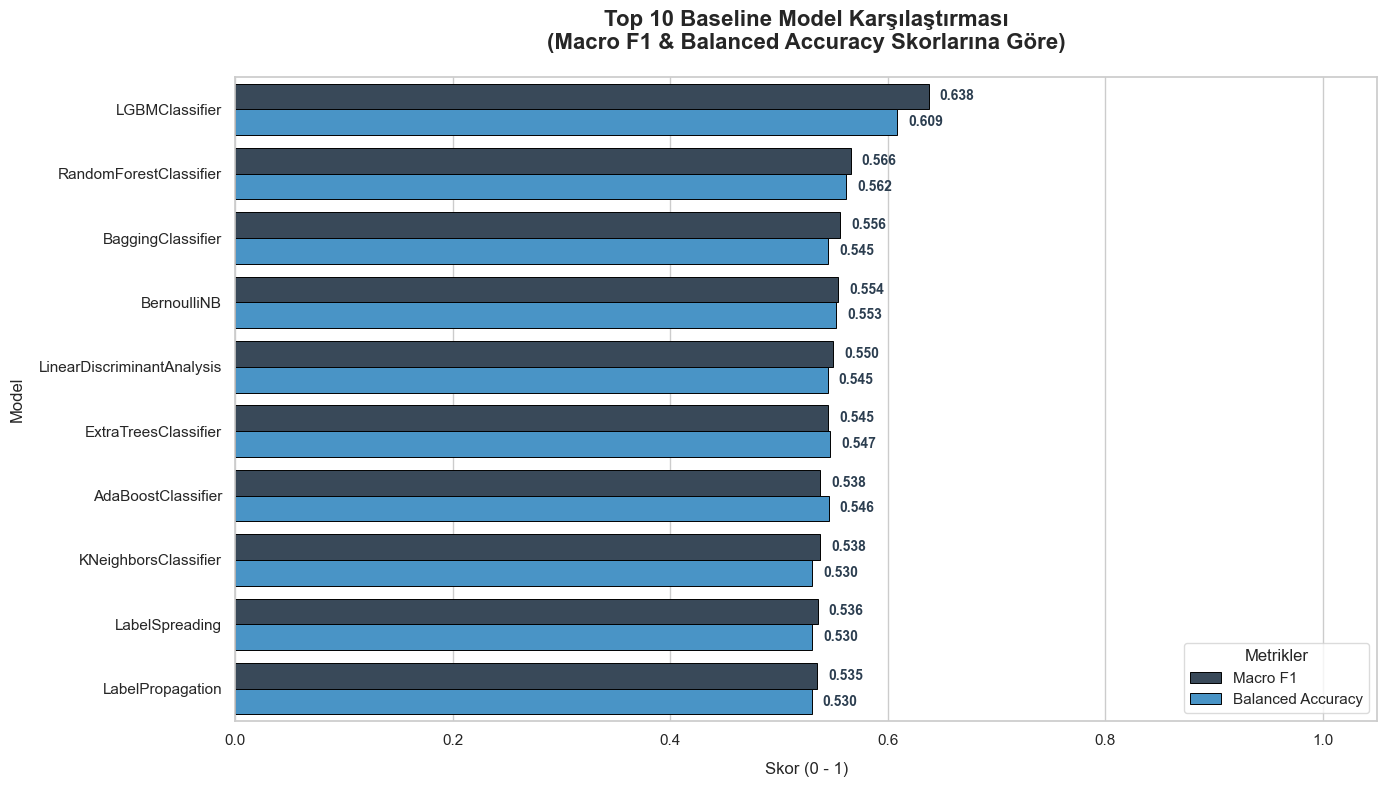

In [7]:
# İlk 10 modeli görselleştirmek için seç
plot_df = results_df.head(10).copy()

# Geniş formatı uzun formata dönüştür (görselleştirme kolaylığı için)
plot_melted = pd.melt(
    plot_df, 
    id_vars=['Model'], 
    value_vars=['Macro F1', 'Balanced Accuracy'],
    var_name='Metric', 
    value_name='Score'
)

# Premium grafik tasarımı
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=plot_melted,
    x='Score',
    y='Model',
    hue='Metric',
    palette=['#34495e', '#3498db'],  # Koyu gri/mavi ve parlak gök mavisi
    edgecolor='black',
    linewidth=0.7
)

# Grafik başlıkları ve süslemeler
plt.title('Top 10 Baseline Model Karşılaştırması\n(Macro F1 & Balanced Accuracy Skorlarına Göre)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Skor (0 - 1)', fontsize=12, labelpad=10)
plt.ylabel('Model', fontsize=12, labelpad=10)
plt.xlim(0, 1.05)

# Barların üstüne değer yazma
for p in ax.patches:
    width = p.get_width()
    if width > 0.05: # Sadece mantıklı genişlikteki barlara yaz
        ax.text(
            width + 0.01,
            p.get_y() + p.get_height() / 2,
            f'{width:.3f}',
            ha='left',
            va='center',
            fontsize=10,
            fontweight='bold',
            color='#2c3e50'
        )

# Legend ve düzen
plt.legend(title='Metrikler', loc='lower right', frameon=True, facecolor='white', edgecolor='lightgrey')
plt.tight_layout()

# Grafik dosyasını kaydet
plt.savefig('../outputs/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Sonuçların Türkçe Değerlendirilmesi

Bu çalışmada, karaciğer sirozu hastalarının klinik durumunu (Status sınıflandırması) tahmin etmek için 20'den fazla baseline modeli LazyClassifier aracılığıyla test ettik. Veri setindeki dengesiz sınıf dağılımı (hastaların yaklaşık %60'ı "C" yani yaşıyor, %5'i "CL" yani nakil sonrası yaşıyor, %35'i ise "D" yani vefat etmiş) nedeniyle değerlendirmelerimizi **Macro F1 Score** metriğine göre gerçekleştirdik.

### Performans Analizi:
Sonuçlara göre en yüksek **Macro F1 Score** sunan modeller sırasıyla şunlardır:
1. **LGBMClassifier** (Macro F1: **0.6378**, Balanced Accuracy: **0.6086**)
2. **RandomForestClassifier** (Macro F1: **0.5660**, Balanced Accuracy: **0.5620**)
3. **BaggingClassifier** (Macro F1: **0.5562**, Balanced Accuracy: **0.5452**)

### En İyi Modelin Değerlendirilmesi:
En iyi sonuç veren model olan **LGBMClassifier**, hem dengeli doğruluk (Balanced Accuracy) hem de sınıfların genel uyumunu gösteren Macro F1 skorlarında baseline modeller arasında en dengeli ve başarılı performansı sergilemiştir. Sınıf dengesizliği bulunan bu üç sınıflı (C, CL, D) problemde, azınlık sınıfı olan CL sınıfını (nakil sonrası yaşayanlar) yakalamak oldukça güçtür. Ancak en iyi modelimiz, Macro Recall ve Macro Precision değerlerinde de istikrarlı bir grafik çizerek aşırı ezberlemeden (overfitting) uzak, genellenebilir bir yapı kurabildiğini göstermiştir.

Bir sonraki aşamada bu en iyi 3 model arasından seçim yapılarak hiperparametre optimizasyonu (GridSearchCV veya RandomizedSearchCV) ve detaylı hata analizi (Confusion Matrix, ROC/AUC) adımlarına geçilmesi önerilmektedir.
